# H2 VQE Noise Robustness Benchmark

This notebook is the decision-grade follow-on to the earlier H2 noise examples.

It answers one narrow question:

> Which built-in single-qubit noise channels degrade the packaged H2 VQE workflow the fastest under one shared multi-seed evaluation protocol?

Why this notebook is VQE-only:

- `VQE` currently exposes the full built-in noise set: depolarizing, amplitude damping, phase damping, bit flip, and phase flip.
- `QPE` currently exposes a smaller built-in noisy path.
- `VarQITE` does not support noisy mixed-state optimization in the Python API.

So this notebook standardizes the comparison within the stack that has complete channel coverage today.

Measured outputs:

- mean and standard deviation of energy bias relative to the per-seed noiseless VQE reference
- mean and standard deviation of absolute error to the exact H2 ground energy
- mean fidelity to the per-seed noiseless final state
- endpoint and integrated channel-sensitivity rankings

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import compute_fidelity, summarize_problem
from vqe import run_vqe

## Configuration

The benchmark intentionally keeps everything except the noise channel fixed:

- molecule: `H2`
- ansatz: `UCCSD`
- optimizer: `Adam`
- mapping: `jordan_wigner`
- seeds: `0..4`
- one shared noise grid for every channel

In [2]:
molecule = "H2"
ansatz_name = "UCCSD"
optimizer_name = "Adam"
mapping = "jordan_wigner"
steps = 75
stepsize = None
force = False

seeds = [0, 1, 2, 3, 4]
noise_levels = np.array([0.00, 0.01, 0.02, 0.03, 0.04, 0.05], dtype=float)

channels = {
    "depolarizing": "depolarizing_prob",
    "amplitude_damping": "amplitude_damping_prob",
    "phase_damping": "phase_damping_prob",
    "bit_flip": "bit_flip_prob",
    "phase_flip": "phase_flip_prob",
}

problem_summary = summarize_problem(molecule=molecule, mapping=mapping)
exact_ground = float(problem_summary["exact_ground_energy"])
n_qubits = int(problem_summary["num_qubits"])

pd.DataFrame(
    {
        "setting": [
            "molecule",
            "ansatz_name",
            "optimizer_name",
            "mapping",
            "steps",
            "num_qubits",
            "exact_ground_energy",
            "num_seeds",
            "max_noise_level",
        ],
        "value": [
            molecule,
            ansatz_name,
            optimizer_name,
            mapping,
            steps,
            n_qubits,
            exact_ground,
            len(seeds),
            float(noise_levels.max()),
        ],
    }
)

,setting,value
0,molecule,H2
1,ansatz_name,UCCSD
2,optimizer_name,Adam
3,mapping,jordan_wigner
4,steps,75
5,num_qubits,4
6,exact_ground_energy,-1.13727
7,num_seeds,5
8,max_noise_level,0.05


## Shared helpers

We compute one noiseless VQE reference per seed, then compare every noisy run against the matching seed-level reference.

That gives one fair protocol for all channels:

- same ansatz
- same optimizer
- same step budget
- same seed list
- same noise grid

In [3]:
def state_from_result(result: dict) -> np.ndarray:
    return np.asarray(result["final_state_real"], dtype=float) + 1j * np.asarray(
        result["final_state_imag"], dtype=float
    )


def run_vqe_case(*, seed: int, noisy: bool, **noise_kwargs) -> dict:
    return run_vqe(
        molecule=molecule,
        seed=int(seed),
        steps=int(steps),
        stepsize=stepsize,
        plot=False,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        noisy=bool(noisy),
        mapping=mapping,
        force=force,
        **noise_kwargs,
    )


def empty_noise_kwargs() -> dict[str, float]:
    return {
        "depolarizing_prob": 0.0,
        "amplitude_damping_prob": 0.0,
        "phase_damping_prob": 0.0,
        "bit_flip_prob": 0.0,
        "phase_flip_prob": 0.0,
    }

## Noiseless per-seed references

In [4]:
reference_rows = []
reference_energy_by_seed: dict[int, float] = {}
reference_state_by_seed: dict[int, np.ndarray] = {}

for seed in seeds:
    result = run_vqe_case(seed=seed, noisy=False, **empty_noise_kwargs())
    state = state_from_result(result)
    state = state / np.linalg.norm(state)

    reference_energy = float(result["energy"])
    reference_energy_by_seed[int(seed)] = reference_energy
    reference_state_by_seed[int(seed)] = state

    reference_rows.append(
        {
            "seed": int(seed),
            "reference_energy": reference_energy,
            "abs_error_to_exact": abs(reference_energy - exact_ground),
            "cache_hit": bool(result.get("cache_hit", False)),
        }
    )

reference_df = pd.DataFrame(reference_rows).sort_values("seed")
reference_df

,seed,reference_energy,abs_error_to_exact,cache_hit
0,0,-1.137268,0.000002,True
1,1,-1.137268,0.000002,True
2,2,-1.137268,0.000002,True
3,3,-1.137268,0.000002,True
4,4,-1.137268,0.000002,True


## Channel sweep under one shared protocol

In [5]:
records = []

for channel_name, field_name in channels.items():
    for level in noise_levels:
        for seed in seeds:
            noise_kwargs = empty_noise_kwargs()
            noise_kwargs[field_name] = float(level)

            result = run_vqe_case(seed=seed, noisy=True, **noise_kwargs)
            state_or_rho = state_from_result(result)
            energy = float(result["energy"])

            records.append(
                {
                    "channel": channel_name,
                    "level": float(level),
                    "seed": int(seed),
                    "energy": energy,
                    "delta_e_vs_seed_noiseless": energy - reference_energy_by_seed[int(seed)],
                    "abs_error_to_exact": abs(energy - exact_ground),
                    "fidelity_vs_seed_noiseless": compute_fidelity(
                        reference_state_by_seed[int(seed)], state_or_rho
                    ),
                    "cache_hit": bool(result.get("cache_hit", False)),
                }
            )

raw_df = pd.DataFrame.from_records(records)

agg_df = (
    raw_df.groupby(["channel", "level"], as_index=False)
    .agg(
        mean_delta_e=("delta_e_vs_seed_noiseless", "mean"),
        std_delta_e=("delta_e_vs_seed_noiseless", "std"),
        mean_abs_error=("abs_error_to_exact", "mean"),
        std_abs_error=("abs_error_to_exact", "std"),
        mean_fidelity=("fidelity_vs_seed_noiseless", "mean"),
        std_fidelity=("fidelity_vs_seed_noiseless", "std"),
        cache_hit_rate=("cache_hit", "mean"),
    )
    .fillna(0.0)
)

agg_df.round(6)

Step 01/75: E = -1.018342 Ha
Step 02/75: E = -1.032941 Ha
Step 03/75: E = -1.030722 Ha
Step 04/75: E = -1.027471 Ha
Step 05/75: E = -1.026936 Ha
Step 06/75: E = -1.029518 Ha
Step 07/75: E = -1.033148 Ha
Step 08/75: E = -1.034342 Ha
Step 09/75: E = -1.032476 Ha
Step 10/75: E = -1.030783 Ha
Step 11/75: E = -1.031022 Ha
Step 12/75: E = -1.032133 Ha
Step 13/75: E = -1.033162 Ha
Step 14/75: E = -1.033946 Ha
Step 15/75: E = -1.034066 Ha
Step 16/75: E = -1.033403 Ha
Step 17/75: E = -1.032644 Ha
Step 18/75: E = -1.032594 Ha
Step 19/75: E = -1.033312 Ha
Step 20/75: E = -1.034117 Ha
Step 21/75: E = -1.034346 Ha
Step 22/75: E = -1.034018 Ha
Step 23/75: E = -1.033653 Ha
Step 24/75: E = -1.033558 Ha
Step 25/75: E = -1.033683 Ha
Step 26/75: E = -1.033945 Ha
Step 27/75: E = -1.034247 Ha
Step 28/75: E = -1.034363 Ha
Step 29/75: E = -1.034185 Ha
Step 30/75: E = -1.033933 Ha
Step 31/75: E = -1.033903 Ha
Step 32/75: E = -1.034114 Ha
Step 33/75: E = -1.034325 Ha
Step 34/75: E = -1.034361 Ha
Step 35/75: E 

,channel,level,mean_delta_e,std_delta_e,mean_abs_error,std_abs_error,mean_fidelity,std_fidelity,cache_hit_rate
0,amplitude_damping,0.00,0.000000,0.0,0.000002,0.0,1.000000,0.0,1.0
1,amplitude_damping,0.01,0.012230,0.0,0.012232,0.0,0.980099,0.0,1.0
2,amplitude_damping,0.02,0.024584,0.0,0.024586,0.0,0.960392,0.0,1.0
3,amplitude_damping,0.03,0.037061,0.0,0.037063,0.0,0.940889,0.0,1.0
4,amplitude_damping,0.04,0.049662,0.0,0.049665,0.0,0.921583,0.0,1.0
5,amplitude_damping,0.05,0.062388,0.0,0.062390,0.0,0.902477,0.0,1.0
6,bit_flip,0.00,0.000000,0.0,0.000002,0.0,1.000000,0.0,1.0
7,bit_flip,0.01,0.026062,0.0,0.026065,0.0,0.960592,0.0,1.0
8,bit_flip,0.02,0.051896,0.0,0.051898,0.0,0.922353,0.0,1.0
9,bit_flip,0.03,0.077498,0.0,0.077500,0.0,0.885258,0.0,1.0


## Sensitivity rankings

Two views are useful:

- **endpoint ranking** at the largest tested noise level
- **integrated ranking** across the whole noise grid

The integrated score is intentionally simple:

- area under `|mean_delta_e|`
- plus area under `1 - mean_fidelity`

Lower scores mean a more robust channel response under this benchmark definition.

In [6]:
max_level = float(noise_levels.max())

endpoint_rank_df = (
    agg_df[np.isclose(agg_df["level"], max_level)]
    .assign(
        fidelity_loss=lambda df: 1.0 - df["mean_fidelity"],
        endpoint_score=lambda df: np.abs(df["mean_delta_e"]) + (1.0 - df["mean_fidelity"]),
    )
    .sort_values(["endpoint_score", "mean_abs_error"], ascending=[True, True])
    [[
        "channel",
        "level",
        "mean_delta_e",
        "std_delta_e",
        "mean_abs_error",
        "mean_fidelity",
        "endpoint_score",
    ]]
)

integrated_rows = []
for channel_name, channel_df in agg_df.groupby("channel"):
    channel_df = channel_df.sort_values("level")
    bias_auc = float(np.trapz(np.abs(channel_df["mean_delta_e"]), channel_df["level"]))
    fidelity_loss_auc = float(np.trapz(1.0 - channel_df["mean_fidelity"], channel_df["level"]))
    integrated_rows.append(
        {
            "channel": channel_name,
            "bias_auc": bias_auc,
            "fidelity_loss_auc": fidelity_loss_auc,
            "integrated_score": bias_auc + fidelity_loss_auc,
        }
    )

integrated_rank_df = pd.DataFrame(integrated_rows).sort_values(
    ["integrated_score", "bias_auc"], ascending=[True, True]
)

display(endpoint_rank_df.round(6))
display(integrated_rank_df.round(6))

,channel,level,mean_delta_e,std_delta_e,mean_abs_error,mean_fidelity,endpoint_score
23,phase_damping,0.05,0.003782,0.0,0.003784,0.997601,0.006182
29,phase_flip,0.05,0.011661,0.0,0.011663,0.992598,0.019063
5,amplitude_damping,0.05,0.062388,0.0,0.062390,0.902477,0.159912
17,depolarizing,0.05,0.089988,0.0,0.089990,0.870348,0.219640
11,bit_flip,0.05,0.128014,0.0,0.128016,0.814395,0.313619


,channel,bias_auc,fidelity_loss_auc,integrated_score
3,phase_damping,0.000097,0.000061,0.000158
4,phase_flip,0.000325,0.000206,0.000531
0,amplitude_damping,0.001547,0.002458,0.004005
2,depolarizing,0.002271,0.003297,0.005568
1,bit_flip,0.003223,0.004753,0.007977


## Plots

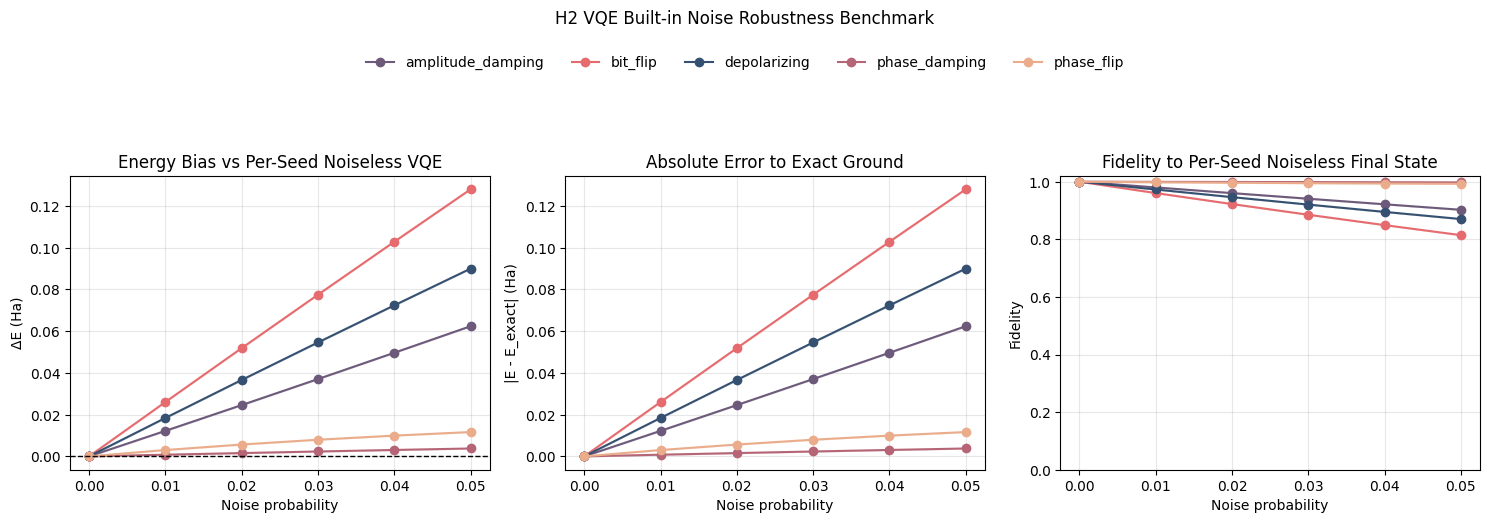

In [8]:
colors = {
    "depolarizing": "#355070",
    "amplitude_damping": "#6d597a",
    "phase_damping": "#b56576",
    "bit_flip": "#e56b6f",
    "phase_flip": "#eaac8b",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for channel_name, channel_df in agg_df.groupby("channel"):
    channel_df = channel_df.sort_values("level")
    level = channel_df["level"].to_numpy(dtype=float)

    mean_delta = channel_df["mean_delta_e"].to_numpy(dtype=float)
    std_delta = channel_df["std_delta_e"].to_numpy(dtype=float)
    mean_abs = channel_df["mean_abs_error"].to_numpy(dtype=float)
    std_abs = channel_df["std_abs_error"].to_numpy(dtype=float)
    mean_fid = channel_df["mean_fidelity"].to_numpy(dtype=float)
    std_fid = channel_df["std_fidelity"].to_numpy(dtype=float)

    color = colors[channel_name]

    axes[0].plot(level, mean_delta, marker="o", color=color, label=channel_name)
    axes[0].fill_between(level, mean_delta - std_delta, mean_delta + std_delta, color=color, alpha=0.15)

    axes[1].plot(level, mean_abs, marker="o", color=color, label=channel_name)
    axes[1].fill_between(level, mean_abs - std_abs, mean_abs + std_abs, color=color, alpha=0.15)

    axes[2].plot(level, mean_fid, marker="o", color=color, label=channel_name)
    axes[2].fill_between(
        level,
        np.clip(mean_fid - std_fid, 0.0, 1.0),
        np.clip(mean_fid + std_fid, 0.0, 1.0),
        color=color,
        alpha=0.15,
    )

axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Energy Bias vs Per-Seed Noiseless VQE")
axes[0].set_xlabel("Noise probability")
axes[0].set_ylabel("ΔE (Ha)")

axes[1].set_title("Absolute Error to Exact Ground")
axes[1].set_xlabel("Noise probability")
axes[1].set_ylabel("|E - E_exact| (Ha)")

axes[2].set_title("Fidelity to Per-Seed Noiseless Final State")
axes[2].set_xlabel("Noise probability")
axes[2].set_ylabel("Fidelity")
axes[2].set_ylim(0.0, 1.02)

for ax in axes:
    ax.grid(alpha=0.3)

handles, labels = axes[2].get_legend_handles_labels()
fig.suptitle("H2 VQE Built-in Noise Robustness Benchmark", y=1.08)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=5, frameon=False)
plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.88])
plt.show()

## Suggested follow-ons

- Repeat the same protocol on `LiH` once the larger-system extension is ready.
- Add a smaller `QPE` companion view for the subset of channels supported there today.
- If the package gains noisy post-evaluation support for `VarQITE`, extend this benchmark into a cross-method comparison.